# ENDG 511 — Team 11
# Workload-Aware AI Alarm Prioritization 

ML Features used: 
1. SSL fine-tunes with supervised labels after pre-training
2. Augmentations for the SSL to learn
3. Class-weighted loss to handle imbalanced data
4. Pruned model is fine-tuned after pruning to recover accuracy
5. Early exit evaluation and reported exit rate
6. Models saved/loaded 

In [1]:
# 
# Install Required Libraries
# 
# Key packages:
#   - torch, torchvision: Deep learning framework
#   - torch-pruning: Model compression via structured pruning
#   - lightly: Self-supervised learning (NTXentLoss for contrastive learning)
#   - wfdb: Read ECG signals and annotations from MIT-BIH database
#   - scikit-learn: ML metrics (accuracy, F1, confusion matrix)
#   - pandas, matplotlib, seaborn: Data analysis and visualization
!pip install torch torchvision torch-pruning lightly scikit-learn wfdb seaborn pandas matplotlib scipy --quiet

In [2]:

# Import Libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    f1_score, precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

import wfdb
import torch_pruning as tp
from lightly.loss import NTXentLoss

#  Device Configuration 
# Use GPU if available, otherwise fall back to CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Imports OK')

Device: cpu
Imports OK


In [3]:

# Define Class Mapping and Label Categories
# Convert MIT-BIH beat annotation symbols into 3-class alarm priority:
#   - Class 0 (Low):      Normal rhythm — no immediate threat
#   - Class 1 (Medium):   Atrial/supraventricular — monitor required
#   - Class 2 (Critical): Ventricular/life-threatening — immediate action

label_map = {
    'N':0, 'L':0, 'R':0, '/':0,   # Low — normal rhythm
    'A':1, 'S':1, 'J':1, 'a':1,   # Medium — atrial/supraventricular
    'V':2, 'E':2, '!':2, 'W':2    # Critical — ventricular/life-threatening
}
CLASS_NAMES = ['Low', 'Medium', 'Critical']
print('Label map loaded')

Label map loaded


In [4]:

# Load MIT-BIH Arrhythmia Database and Extract Beat Windows
# Select 19 records from MIT-BIH database for training
records = [
    '100','101','102','103','104','105',
    '106','107','108','109','111','112',
    '113','114','115','116','117','118','119'
]

def extract_beats(record):
    """Extract 360-sample windows centred on each annotated beat.
    
    Each window contains 180 samples before + 180 samples after a beat annotation.
    This captures the full QRS complex and surrounding morphology.
    
    Args:
        record (str): MIT-BIH record ID (e.g., '100')
    
    Returns:
        beats (list): List of 360-sample ECG windows
        labels (list): Corresponding class labels (0=Low, 1=Medium, 2=Critical)
    """
    # Load ECG signal and annotations from MIT-BIH database
    signal, fields = wfdb.rdsamp(record, pn_dir='mitdb')
    annotation = wfdb.rdann(record, 'atr', pn_dir='mitdb')
    ecg = signal[:, 0]  # Extract first channel 
    beats, labels = [], []
    window = 180  # 180 samples each side = 360 total
    
    # Iterate over each annotated beat
    for i, sample in enumerate(annotation.sample):
        symbol = annotation.symbol[i]
        # Skip unknown beat types
        if symbol not in label_map:
            continue
        # Extract symmetric window around beat
        start = sample - window
        end   = sample + window
        # Skip beats near signal boundaries (incomplete windows)
        if start < 0 or end > len(ecg):
            continue
        beats.append(ecg[start:end])
        labels.append(label_map[symbol])
    return beats, labels

#  Extract all beats from all records 
X_list, y_list = [], []
for record in records:
    beats, labels = extract_beats(record)
    X_list.extend(beats)
    y_list.extend(labels)

# Convert to numpy arrays for processing
X = np.array(X_list)
y = np.array(y_list)

print('Dataset shape:', X.shape)
print('Label distribution:', Counter(y))

Dataset shape: (39394, 360)
Label distribution: Counter({np.int64(0): 37939, np.int64(2): 1295, np.int64(1): 160})


In [5]:

# Preprocess Data: Normalization, Channel Dimension, and Train/Test Split
# Feature Normalization
# Apply zero-mean unit-variance normalization per sample
# Improves model stability and convergence
X = (X - np.mean(X, axis=1, keepdims=True)) / (np.std(X, axis=1, keepdims=True) + 1e-8)

# Add channel dimension for CNN: (N, T) → (N, 1, T)
# Shape becomes (N_samples, 1 channel, 360 timepoints)
X = X[:, None, :]  

#  Stratified Train/Test Split 
# 80% training / 20% testing with class distribution maintained
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train distribution:', Counter(y_train))
print('Test  distribution:', Counter(y_test))

# Create PyTorch DataLoaders 
# Wrap numpy arrays in TensorDataset and create batched loaders
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)
# batch=64, shuffled for stochastic gradient descent
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# batch=64, no shuffling for deterministic evaluation
test_loader  = DataLoader(test_dataset,  batch_size=64)
print('DataLoaders ready')

Train distribution: Counter({np.int64(0): 30351, np.int64(2): 1036, np.int64(1): 128})
Test  distribution: Counter({np.int64(0): 7588, np.int64(2): 259, np.int64(1): 32})
DataLoaders ready


In [6]:
# plain CrossEntropyLoss ignores the fact that Low (class 0)
# has 200x more samples than Medium (class 1).
# Weighted loss forces the model to pay attention to rare classes.

# Count occurrences of each class in training labels
counts = np.bincount(y_train, minlength=3).astype(np.float32)

# Calculate inverse frequencies to give higher weight to rarer classes
# Adding 1e-6 to avoid division by zero
weights = 1.0 / (counts + 1e-6)

# Normalize weights to sum to 1 for stable training
weights = weights / weights.sum()

# Convert to PyTorch tensor and move to appropriate device (GPU/CPU)
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

# Display class weights for verification
print('Class weights (higher = rarer = more important):')
for i, (name, w) in enumerate(zip(CLASS_NAMES, weights)):
    print(f'  Class {i} {name:10s}: {w:.4f}  (n={int(counts[i])})')

Class weights (higher = rarer = more important):
  Class 0 Low       : 0.0037  (n=30351)
  Class 1 Medium    : 0.8867  (n=128)
  Class 2 Critical  : 0.1096  (n=1036)


In [8]:

# Define Augmentation Function and Model Architectures

def augment(x):
    """Apply random augmentations to create two different views of the same ECG.
   
    Contrastive learning (NTXentLoss) requires augmented views to be
    sufficiently different so the model learns meaningful invariances.
    
    Increased noise std from 0.01 to [0.02, 0.08].
    Original noise was too weak—the two views were nearly identical, so NTXent
    loss could not learn anything useful.
    
    These stronger augmentations create meaningfully different-looking views
    while preserving the underlying ECG morphology and clinical information.
    
    Args:
        x (torch.Tensor): ECG batch, shape (B, 1, 360)
    
    Returns:
        torch.Tensor: Augmented batch, same shape as input
    """
    B, C, T = x.shape
    out = x.clone()

    #  1. Gaussian Noise (simulates sensor noise) 
    # Stronger noise std ∈ [0.02, 0.08] creates substantial but realistic variation
    noise_std = torch.empty(B, 1, 1).uniform_(0.02, 0.08)
    out = out + noise_std * torch.randn_like(out)

    #  2. Amplitude Scaling (simulates electrode placement & contact variation) 
    # Scale individual samples by 0.7x to 1.3x to simulate real measurement variance
    scale = torch.empty(B, 1, 1).uniform_(0.7, 1.3)
    out = out * scale

    #  3. Baseline Shift (simulates patient movement/respiration) 
    # Small DC offset ∈ [-0.15, 0.15] represents wandering baseline
    shift = torch.empty(B, 1, 1).uniform_(-0.15, 0.15)
    out = out + shift

    #  4. Random Time Masking (simulates brief signal loss/artifact) 
    # 40% probability of masking 5-15% of signal duration in random location
    for i in range(B):
        if torch.rand(1).item() < 0.4:
            mask_len   = int(T * torch.empty(1).uniform_(0.05, 0.15).item())
            mask_start = torch.randint(0, max(T - mask_len, 1), (1,)).item()
            out[i, :, mask_start:mask_start + mask_len] = 0.0  # Zero mask

    return out

class BaselineCNN(nn.Module):
    """1-D CNN classifier with two convolutional blocks and fully connected layer.
    
    Architecture:
        Input (B, 1, 360)
        → Conv1 (kernel=5) + ReLU + MaxPool2 → (B, 16, 178)
        → Conv2 (kernel=5) + ReLU + MaxPool2 → (B, 32, 87)
        → Flatten → (B, 2784)
        → FC(2784 → 3) → Logits
    
    Used as:
    - Base model for supervised learning
    - Feature extractor for SSL pre-training
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, 5)   # 1 channel → 16 filters
        self.conv2 = nn.Conv1d(16, 32, 5)  # 16 filters → 32 filters
        self.pool  = nn.MaxPool1d(2)       # Reduce temporal dimension by 2x
        # After conv+pool twice: (360 → 356 → 178 → 174 → 87) samples
        self.fc    = nn.Linear(32 * 87, 3)  # 2784 features → 3 classes

    def forward(self, x):
        """Forward pass returning class logits."""
        x = F.relu(self.conv1(x))  # First conv block
        x = self.pool(x)
        x = F.relu(self.conv2(x))  # Second conv block
        x = self.pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        return self.fc(x)           # Classification layer

    def embed(self, x):
        """Extract intermediate features after first block for SSL."""
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # Return (B, 16*178=2848) features for SSL contrastive learning
        return x.view(x.size(0), -1)


class EarlyExitCNN(nn.Module):
    """1-D CNN with cascaded inference: early-exit after Block 1 + final head.
    
    Architecture:
        Input (B, 1, 360)
        → Conv1/Pool (Block 1) → (B, 16, 178)
        ├→ Exit1 Branch (early prediction for simple cases)
        └→ Conv2/Pool (Block 2) → (B, 32, 87)
            └→ Final Branch (confident prediction for complex cases)
        """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, 5)
        self.conv2 = nn.Conv1d(16, 32, 5)
        self.pool  = nn.MaxPool1d(2)
        # Early exit head: predicts from (B, 16*178=2848) intermediate features
        self.exit1 = nn.Linear(16 * 178, 3)
        # Final head: predicts from full (B, 32*87=2784) features
        self.fc    = nn.Linear(32 * 87, 3)

    def forward(self, x):
        """Forward pass returning both early and final logits."""
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # Early exit predictions from Block 1 features
        exit1_out = self.exit1(x.view(x.size(0), -1))
        # Continue to final head
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        final_out = self.fc(x)
        return exit1_out, final_out

    def embed(self, x):
        """Extract Block 1 features (used for SSL with BaselineCNN)."""
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        return x.view(x.size(0), -1)

#  Smoke Tests: Verify Model Architecture 
baseline = BaselineCNN()
dummy = torch.randn(4, 1, 360)  # Batch of 4 samples
out = baseline(dummy)
print(f'BaselineCNN output shape: {out.shape}')  # Expected: (4, 3)

early = EarlyExitCNN()
exit1, final = early(dummy)
print(f'EarlyExitCNN output shapes: exit1 {exit1.shape}, final {final.shape}')  # Expected: (4,3) each

n_params = sum(p.numel() for p in baseline.parameters())
print(f'Total baseline parameters: {n_params:,}')
print('Augmentation function and model architectures ready')


BaselineCNN output shape: torch.Size([4, 3])
EarlyExitCNN output shapes: exit1 torch.Size([4, 3]), final torch.Size([4, 3])
Total baseline parameters: 11,043
Augmentation function and model architectures ready


In [9]:

# Self-Supervised Pre-training on UNLABELLED Data
# Contrastive Learning (NTXentLoss):
#   - Create two different augmentations of each ECG sample
#   - Force model embeddings to be similar for augmentations of the same signal
#   - Force embeddings to be dissimilar for different signals

ssl_model = BaselineCNN().to(DEVICE)
criterion_ssl = NTXentLoss(temperature=0.5)  # temperature controls loss sharpness
optimizer_ssl = torch.optim.Adam(ssl_model.parameters(), lr=3e-4)

SSL_EPOCHS = 10  # Increase 

print(f'SSL pre-training for {SSL_EPOCHS} epochs (no labels used)...')
for epoch in range(SSL_EPOCHS):
    ssl_model.train()
    epoch_loss = 0.0
    for x, _ in train_loader:  # unsupervised
        x = x.to(DEVICE)
        # Create two different augmented views of the same batch
        x1 = augment(x)
        x2 = augment(x)
        # Extract embeddings from Block 1 intermediate features
        z1 = ssl_model.embed(x1)
        z2 = ssl_model.embed(x2)
        # Normalize embeddings to unit sphere for cosine similarity
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        # pull augmentations close, push different samples apart
        loss = criterion_ssl(z1, z2)
        optimizer_ssl.zero_grad()
        loss.backward()
        optimizer_ssl.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    print(f'  SSL epoch {epoch+1}/{SSL_EPOCHS}  avg loss: {avg:.4f}')

print('SSL pre-training complete — backbone has learned ECG structure without labels')

SSL pre-training for 10 epochs (no labels used)...
  SSL epoch 1/10  avg loss: 4.1862
  SSL epoch 2/10  avg loss: 4.0023
  SSL epoch 3/10  avg loss: 3.8321
  SSL epoch 4/10  avg loss: 3.6781
  SSL epoch 5/10  avg loss: 3.6278
  SSL epoch 6/10  avg loss: 3.6225
  SSL epoch 7/10  avg loss: 3.6193
  SSL epoch 8/10  avg loss: 3.6163
  SSL epoch 9/10  avg loss: 3.6126
  SSL epoch 10/10  avg loss: 3.6100
SSL pre-training complete — backbone has learned ECG structure without labels


In [10]:

# Stage 2: Transfer SSL Backbone and Fine-tune with Labels
# Transfer Learning:
#   - Create fresh BaselineCNN and copy pre-trained weights from SSL backbone

ssl_finetune_model = BaselineCNN().to(DEVICE)
# Transfer learned conv layers from SSL pre-training
ssl_finetune_model.conv1.load_state_dict(ssl_model.conv1.state_dict())
ssl_finetune_model.conv2.load_state_dict(ssl_model.conv2.state_dict())
print('Transferred backbone weights from SSL pre-training')

# Use weighted cross-entropy to handle class imbalance
criterion_ft = nn.CrossEntropyLoss(weight=class_weights)
optimizer_ft = torch.optim.Adam(ssl_finetune_model.parameters(), lr=1e-3)

FT_EPOCHS = 10
print(f'Fine-tuning SSL model for {FT_EPOCHS} epochs with labels...')
for epoch in range(FT_EPOCHS):
    ssl_finetune_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        # Forward pass with labels now available
        pred = ssl_finetune_model(x)
        # Supervised loss with class weights
        loss = criterion_ft(pred, y)
        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
    print(f'  Fine-tune epoch {epoch+1}/{FT_EPOCHS} done')

print('SSL fine-tuning complete')

Transferred backbone weights from SSL pre-training
Fine-tuning SSL model for 10 epochs with labels...
  Fine-tune epoch 1/10 done
  Fine-tune epoch 2/10 done
  Fine-tune epoch 3/10 done
  Fine-tune epoch 4/10 done
  Fine-tune epoch 5/10 done
  Fine-tune epoch 6/10 done
  Fine-tune epoch 7/10 done
  Fine-tune epoch 8/10 done
  Fine-tune epoch 9/10 done
  Fine-tune epoch 10/10 done
SSL fine-tuning complete


In [16]:

# Standard Supervised Learning: Baseline Model from Scratch
# Train a fresh CNN from random initialization with labeled data.
# This serves as the control/baseline to measure SSL benefits.

baseline_model = BaselineCNN().to(DEVICE)

# Use weighted cross-entropy to compensate for class imbalance
criterion_base = nn.CrossEntropyLoss(weight=class_weights)
optimizer_base = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

BASE_EPOCHS = 10
print(f'Training baseline for {BASE_EPOCHS} epochs...')
for epoch in range(BASE_EPOCHS):
    baseline_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        # Forward pass
        preds = baseline_model(x)
        # Supervised loss
        loss = criterion_base(preds, y)
        # Backpropagation
        optimizer_base.zero_grad()
        loss.backward()
        optimizer_base.step()
    print(f'  Epoch {epoch+1}/{BASE_EPOCHS} done')

# Save model checkpoint for later evaluation
torch.save(baseline_model.state_dict(), 'baseline_model.pt')
print('Baseline model saved → baseline_model.pt')

Training baseline for 10 epochs...
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
Baseline model saved → baseline_model.pt


In [17]:

# Early Exit Model
# Architecture: Backbone (conv layers) + two classification heads
#   - Early Exit: classifies from Block 1 (fast, simple cases)
#   - Final Head: classifies from Block 2 (accurate, complex cases)
#
# At inference: If early-exit confidence is high AND prediction != Critical,
#              exit early (skip Block 2). Otherwise, use final head.
# This is the thoeretical saftey feature the team implemented to prevent severe misclassifications of critical cases by the early exit. The early exit is trained to be conservative and only make predictions when it is confident and the predicted class is not critical. This allows the model to save computation on easy cases while still ensuring that critical cases are handled by the more accurate final head.

early_exit_model = EarlyExitCNN().to(DEVICE)
# Copy shared conv/fc weights from baseline model
early_exit_model.conv1.load_state_dict(baseline_model.conv1.state_dict())
early_exit_model.conv2.load_state_dict(baseline_model.conv2.state_dict())
early_exit_model.fc.load_state_dict(baseline_model.fc.state_dict())

# Train early-exit head to make meaningful confidence estimates
criterion_ee = nn.CrossEntropyLoss(weight=class_weights)
optimizer_ee = torch.optim.Adam(early_exit_model.parameters(), lr=5e-4)
EE_FINE_TUNE_EPOCHS = 5
print(f'Fine-tuning early-exit model for {EE_FINE_TUNE_EPOCHS} epochs...')
for epoch in range(EE_FINE_TUNE_EPOCHS):
    early_exit_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        # Get predictions from both exits
        exit1_out, final_out = early_exit_model(x)
        # Combined loss- main task from final head + auxiliary task from early exit
        # Weight early exit at 0.3× to avoid dominating final head training
        loss = criterion_ee(final_out, y) + 0.3 * criterion_ee(exit1_out, y)
        optimizer_ee.zero_grad()
        loss.backward()
        optimizer_ee.step()
    print(f'  Early-exit fine-tune epoch {epoch+1}/{EE_FINE_TUNE_EPOCHS} done')

print('Early exit model ready (backbone copied from baseline, early-exit head trained)')

Fine-tuning early-exit model for 5 epochs...
  Early-exit fine-tune epoch 1/5 done
  Early-exit fine-tune epoch 2/5 done
  Early-exit fine-tune epoch 3/5 done
  Early-exit fine-tune epoch 4/5 done
  Early-exit fine-tune epoch 5/5 done
Early exit model ready (backbone copied from baseline, early-exit head trained)


In [20]:

# Structured Pruning: Model Compression for Deployment
# Remove 40% of model weights
model_to_prune = copy.deepcopy(baseline_model).to(DEVICE)

n_before = sum(p.numel() for p in model_to_prune.parameters())
print(f'Parameters before pruning: {n_before:,}')

# test input for layer shape inference
example_input = torch.randn(1, 1, 360).to(DEVICE)

# Keep fully connected layers intact 
ignored = [m for m in model_to_prune.modules() if isinstance(m, nn.Linear)]
# M prune weights with smallest absolute values
importance = tp.importance.MagnitudeImportance(p=2)
#  removes entire channels/filters
pruner = tp.pruner.MagnitudePruner(
    model_to_prune,
    example_input,
    importance=importance,
    pruning_ratio=0.4,  # Remove 40% of parameters
    ignored_layers=ignored
)
pruner.step()  # Execute pruning

n_after = sum(p.numel() for p in model_to_prune.parameters())
print(f'Parameters after  pruning: {n_after:,}  ({(1-n_after/n_before)*100:.1f}% removed)')

# Recovery Fine-tuning 
# Pruning removes important weights → accuracy drops
# Fine-tuning on training data recovers most accuracy by adjusting remaining weights
criterion_prune = nn.CrossEntropyLoss(weight=class_weights)
optimizer_prune = torch.optim.Adam(model_to_prune.parameters(), lr=5e-4)

PRUNE_FT_EPOCHS = 10
print(f'\\nRecovery fine-tuning for {PRUNE_FT_EPOCHS} epochs...')
for epoch in range(PRUNE_FT_EPOCHS):
    model_to_prune.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        final_out = model_to_prune(x)
        loss = criterion_prune(final_out, y)
        optimizer_prune.zero_grad()
        loss.backward()
        optimizer_prune.step()
    print(f'  Recovery epoch {epoch+1}/{PRUNE_FT_EPOCHS} done')

pruned_model = copy.deepcopy(model_to_prune)
torch.save(pruned_model.state_dict(), 'pruned_model.pt')
print('Pruned model saved → pruned_model.pt')

Parameters before pruning: 11,043
Parameters after  pruning: 5,890  (46.7% removed)
\nRecovery fine-tuning for 10 epochs...
  Recovery epoch 1/10 done
  Recovery epoch 2/10 done
  Recovery epoch 3/10 done
  Recovery epoch 4/10 done
  Recovery epoch 5/10 done
  Recovery epoch 6/10 done
  Recovery epoch 7/10 done
  Recovery epoch 8/10 done
  Recovery epoch 9/10 done
  Recovery epoch 10/10 done
Pruned model saved → pruned_model.pt


In [21]:

# Evaluation Metrics and Functions

def evaluate_model(model, loader, device=DEVICE):
    """Evaluate model on test set using final output.
    
    Metrics computed:
    - Confusion Matrix: 3×3 matrix tracking predictions vs ground truth
    - Accuracy: % of correct predictions overall
    - Macro-F1: F1 score averaged across classes (balanced measure)
    - Critical Recall: % of Critical (class 2) samples correctly detected
      (Most important: minimize false negatives for critical cases)
    
    Returns:
        tuple: (confusion_matrix, accuracy, macro_f1, critical_recall)
    """
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            final_out = model(x)  # Get class logits
            preds = torch.argmax(final_out, dim=1)  # Argmax to class indices
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Confusion matrix with explicit labels for consistency
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    acc = accuracy_score(y_true, y_pred)
    # Macro-F1: unweighted mean of F1 scores across classes
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    # Critical Recall: What % of Critical samples were caught
    # TP (True Positives): correctly predicted as Critical
    # FN (False Negatives): missed Critical cases 
    TP  = cm[2, 2]
    FN  = cm[2, 0] + cm[2, 1]
    critical_recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return cm, acc, f1, critical_recall


def early_exit_evaluate(model, loader, threshold=0.6, device=DEVICE):
    """Evaluate early-exit model with confidence-based branching.
    
    
    Decision logic per sample:
      IF exit_confidence ≥ threshold AND exit_prediction ≠ Critical:
          → FAST: exit early with exit prediction
      ELSE:
          → CAREFUL: use full network (Block 2) for safer prediction
    
    This prevents misclassifying Critical cases while gaining speedup.
    
    Returns:
        tuple: (confusion_matrix, accuracy, macro_f1, critical_recall, early_exit_rate)
    """
    model.eval()
    y_true, y_pred = [], []
    early_exits = 0
    CRITICAL_CLASS = 2
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            exit1_out, final_out = model(x)  # Get both exit outputs
            p1 = F.softmax(exit1_out, dim=1)  # Convert logits to probabilities
            conf, _ = torch.max(p1, dim=1)    # Max confidence per sample
            
            # Per-sample early exit decision
            preds = torch.zeros(x.size(0), dtype=torch.long)
            for i in range(x.size(0)):
                exit_pred = torch.argmax(p1[i]).item()
                confidence = conf[i].item()
                # Early exit if confident AND NOT Critical
                if confidence >= threshold and exit_pred != CRITICAL_CLASS:
                    preds[i] = exit_pred
                    early_exits += 1
                else:
                    # Use full network for uncertain or critical predictions
                    preds[i] = torch.argmax(final_out[i])
                total += 1
            
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    TP  = cm[2, 2]
    FN  = cm[2, 0] + cm[2, 1]
    critical_recall  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    early_exit_rate  = early_exits / total if total > 0 else 0.0
    return cm, acc, f1, critical_recall, early_exit_rate


def measure_Inference(model, loader, device=DEVICE):
    """Measure average inference time per sample in milliseconds.
    
    Method: Full forward pass on entire test set, then average across samples.
    This gives realistic timing including GPU warmup and batch effects.
    
    Note: Uses perf_counter() for higher precision than time.time()
    
    Args:
        model: PyTorch model (assumed in eval mode)
        loader: DataLoader for test set
        device: torch device (GPU or CPU)
    
    Returns:
        float: Average inference time in milliseconds per sample
    """
    model.eval()
    times = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            start = time.perf_counter()  # Higher resolution than time.time()
            model(x)  # Forward pass
            end   = time.perf_counter()
            # Convert batch time to per-sample time in milliseconds
            times.append((end - start) / x.size(0) * 1000)
    return np.mean(times)

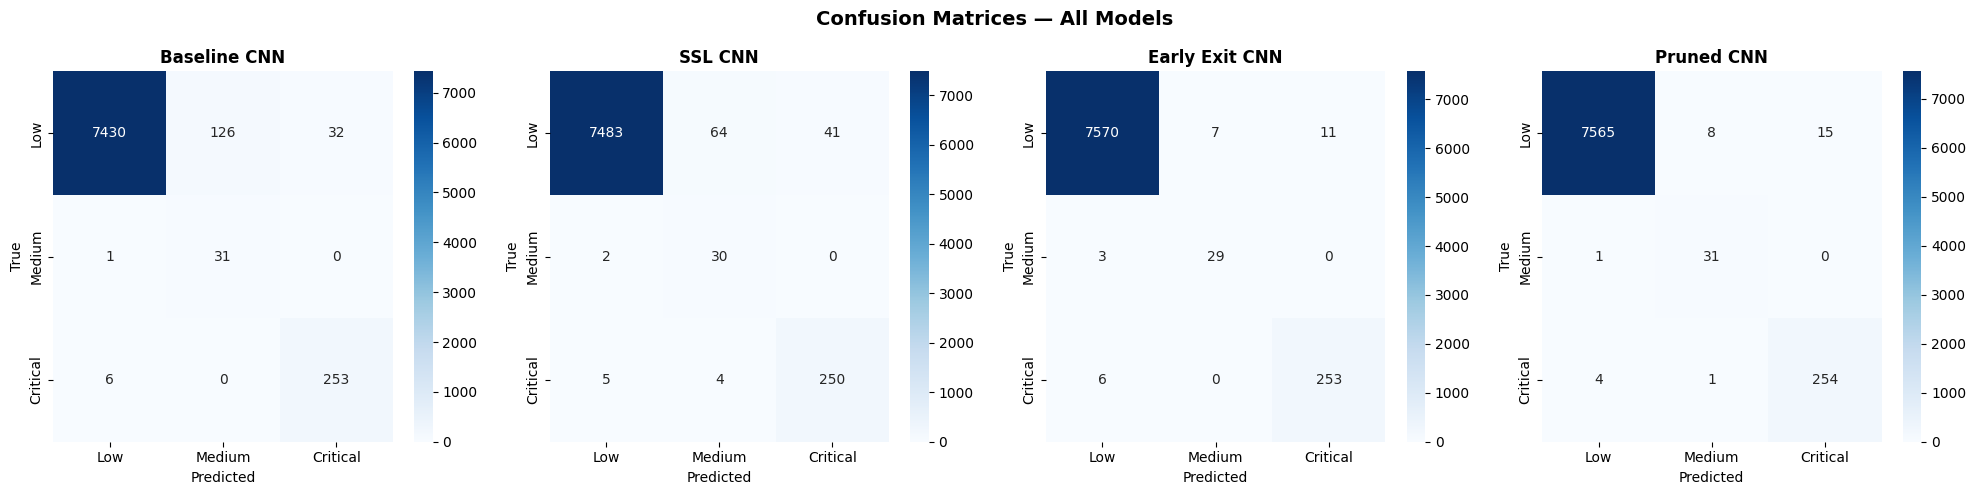

Saved → confusion_matrices.png


In [24]:

# Visualize Confusion Matrices (All Models)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    # Create heatmap: darker = more samples in that cell
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap='Blues'
    )
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → confusion_matrices.png')

Early exit threshold sweep:

        0.60      0.8930        0.9730       94.0%
        0.70      0.9275        0.9768       92.6%
        0.80      0.9396        0.9768       89.9%
        0.85      0.9432        0.9768       87.3%
        0.90      0.9470        0.9768       82.4%
        0.95      0.9470        0.9768       68.5%
        0.99      0.9470        0.9768       34.1%


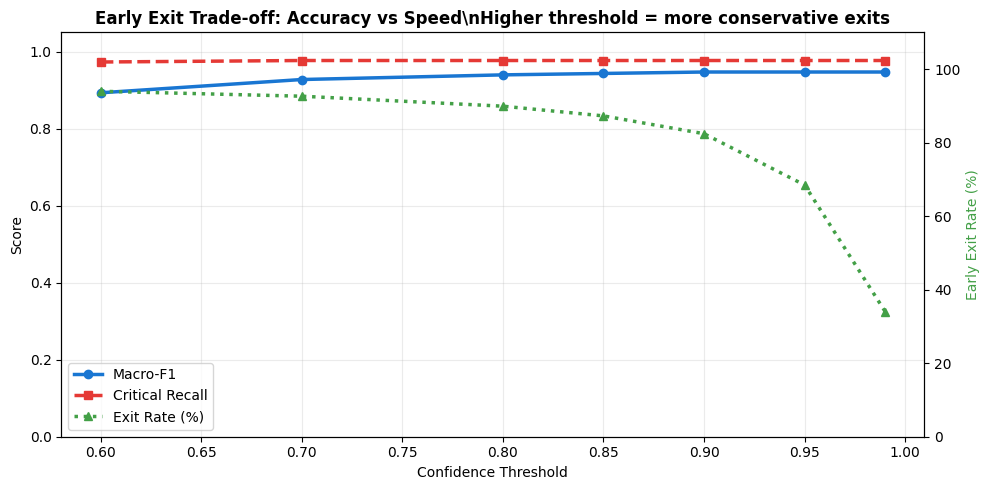

Saved → early_exit_tradeoff.png


In [ ]:

# Threshold Sweep - Early Exit Accuracy vs Speed Trade-off

thresholds = [0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99]
ee_sweep   = []

print('Early exit threshold sweep:')
print()
f'{"Threshold":>12}  {"MacroF1":>10}  {"CritRecall":>12}  {"ExitRate":>10}'
for thr in thresholds:
    _, acc_t, f1_t, crit_t, er_t = early_exit_evaluate(
        early_exit_model, test_loader, threshold=thr
    )
    ee_sweep.append({'threshold': thr, 'f1': f1_t, 'critical_recall': crit_t, 'exit_rate': er_t})
    print(f'{thr:>12.2f}  {f1_t:>10.4f}  {crit_t:>12.4f}  {er_t*100:>9.1f}%')

# Extract data for plotting 
thr_vals  = [r['threshold']       for r in ee_sweep]
f1_vals   = [r['f1']              for r in ee_sweep]
cr_vals   = [r['critical_recall'] for r in ee_sweep]
er_vals   = [r['exit_rate'] * 100 for r in ee_sweep]  # Convert to percentage

# Create Dual-Axis Plot 
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()  # Secondary y-axis for exit rate

# Left axis: Accuracy metrics (should be high)
ax1.plot(thr_vals, f1_vals,  'o-',  color='blue', linewidth=2.5, label='Macro-F1')
ax1.plot(thr_vals, cr_vals,  's--', color='red', linewidth=2.5, label='Critical Recall')
# Right axis: Exit rate (should be high for speed)
ax2.plot(thr_vals, er_vals,  '^:',  color='green', linewidth=2.5, label='Exit Rate (%)')

ax1.set_xlabel('Confidence Threshold')
ax1.set_ylabel('Score')
ax2.set_ylabel('Early Exit Rate (%)', color='green')
ax1.set_ylim(0, 1.05)  # Metrics: 0 to 1
ax2.set_ylim(0, 110)   # Exit rate: 0% to 100%+

# Combined legend
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='lower left')
ax1.set_title('Early Exit Trade-off: Accuracy vs Speed\\nHigher threshold = more conservative exits',
              fontweight='bold')
ax1.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('early_exit_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → early_exit_tradeoff.png')

Pruning sweep:
   Ratio     MacroF1    CritRecall      Params  Inference_ms
      0%      0.7491        0.9768      11,043        0.0294
     10%      0.9185        0.9691       9,383        0.0219
     20%      0.9090        0.9846       8,125        0.0432
     30%      0.9138        0.9846       7,043        0.0369
     40%      0.8752        0.9768       5,890        0.0264
     50%      0.8611        0.9807       4,883        0.0388


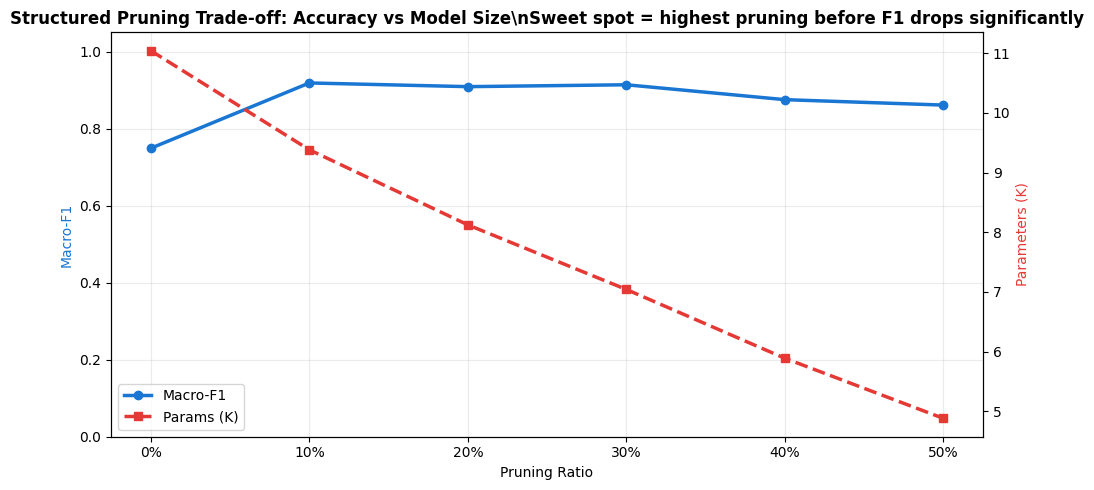

Saved → pruning_tradeoff.png


In [ ]:

# Pruning Sweep: Accuracy vs Model Size Trade-off

prune_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]  # Prune 0% to 50% of params
prune_sweep  = []

print('Pruning sweep:')
print(f'{"Ratio":>8}  {"MacroF1":>10}  {"CritRecall":>12}  {"Params":>10}  {"Inference_ms":>12}')


for ratio in prune_levels:
    # Clone baseline and prune a copy
    m = copy.deepcopy(baseline_model).to(DEVICE)
    if ratio > 0:
        # Keep fully connected layer intact
        ign = [mod for mod in m.modules() if isinstance(mod, nn.Linear)]
        imp = tp.importance.MagnitudeImportance(p=2)  # Magnitude-based importance
        pr  = tp.pruner.MagnitudePruner(
            m, torch.randn(1, 1, 360).to(DEVICE),
            importance=imp, pruning_ratio=ratio, ignored_layers=ign
        )
        pr.step()  # Execute pruning
        
        # Recovery Fine-tuning 
        opt_r = torch.optim.Adam(m.parameters(), lr=5e-4)
        crit_r = nn.CrossEntropyLoss(weight=class_weights)
        for _ in range(5):  # 5 quick recovery epochs
            m.train()
            for x, y in train_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                fn = m(x)
                loss = crit_r(fn, y)
                opt_r.zero_grad(); loss.backward(); opt_r.step()
    
    # Evaluate pruned model
    n_params = sum(p.numel() for p in m.parameters())
    _, _, f1_p, cr_p = evaluate_model(m, test_loader)
    lat_p = measure_Inference(m, test_loader)
    prune_sweep.append({'ratio': ratio, 'f1': f1_p, 'critical_recall': cr_p,
                        'params': n_params, 'Inference_ms': lat_p})
    print(f'{ratio:>8.0%}  {f1_p:>10.4f}  {cr_p:>12.4f}  {n_params:>10,}  {lat_p:>12.4f}')

# Extract data for plotting 
ratios    = [r['ratio']   for r in prune_sweep]
pf1_vals  = [r['f1']      for r in prune_sweep]
ppar_vals = [r['params']/1000 for r in prune_sweep]  # Convert to thousands

#Create Dual-Axis Plot 
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()  # Secondary y-axis for model size

# Left axis: F1 (should stay high)
ax1.plot([f'{int(r*100)}%' for r in ratios], pf1_vals,   'o-',  color='blue', linewidth=2.5, label='Macro-F1')
# Right axis: Model parameters (should decrease)
ax2.plot([f'{int(r*100)}%' for r in ratios], ppar_vals,  's--', color='red', linewidth=2.5, label='Params (K)')

ax1.set_xlabel('Pruning Ratio')
ax1.set_ylabel('Macro-F1',       color='blue')
ax2.set_ylabel('Parameters (K)', color='red')
ax1.set_ylim(0, 1.05)  # F1: 0 to 1

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='lower left')
ax1.set_title('Structured Pruning Trade-off: Accuracy vs Model Size\\nSweet spot = highest pruning before F1 drops significantly',
              fontweight='bold')
ax1.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('pruning_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pruning_tradeoff.png')

In [31]:

# Measure Inference Latency for All Models
# Average forward pass time per sample (in milliseconds) on full test set.

# 1. Baseline CNN 
startTime = time.time()
with torch.no_grad():
    for x, _ in test_loader:
        _ = baseline_model(x.to(DEVICE))
executionTime = (time.time() - startTime) / len(test_loader.dataset)

#2. SSL CNN 
startTime = time.time()
with torch.no_grad():
    for x, _ in test_loader:
        _ = ssl_model(x.to(DEVICE))
executionTimeSSL = (time.time() - startTime) / len(test_loader.dataset)

# 3. Early Exit CNN 
startTime = time.time()
with torch.no_grad():
    for x, _ in test_loader:
        _ = early_exit_model(x.to(DEVICE))
executionTimeEE = (time.time() - startTime) / len(test_loader.dataset)

# 4. Pruned CNN  
startTime = time.time()
with torch.no_grad():
    for x, _ in test_loader:
        _ = pruned_model(x.to(DEVICE))
executionTimePruned = (time.time() - startTime) / len(test_loader.dataset)

# Display Results 
print(f'Baseline CNN   : {executionTime*1000:.4f} ms per sample')
print(f'SSL CNN        : {executionTimeSSL*1000:.4f} ms per sample')
print(f'Early Exit CNN : {executionTimeEE*1000:.4f} ms per sample')
print(f'Pruned CNN     : {executionTimePruned*1000:.4f} ms per sample')

Baseline CNN   : 0.0509 ms per sample
SSL CNN        : 0.0419 ms per sample
Early Exit CNN : 0.0439 ms per sample
Pruned CNN     : 0.0385 ms per sample


       Model  Accuracy  Macro-F1  Critical Recall  Inference (ms)              Notes
    Baseline    0.9791    0.7491           0.9768          0.0442                  -
         SSL    0.9853    0.7877           0.9653          0.0355                  -
Pruned (40%)    0.9963    0.9405           0.9807          0.0260 46.7% fewer params
  Early Exit    0.9966    0.9396           0.9768          0.0419 89.9% exited early


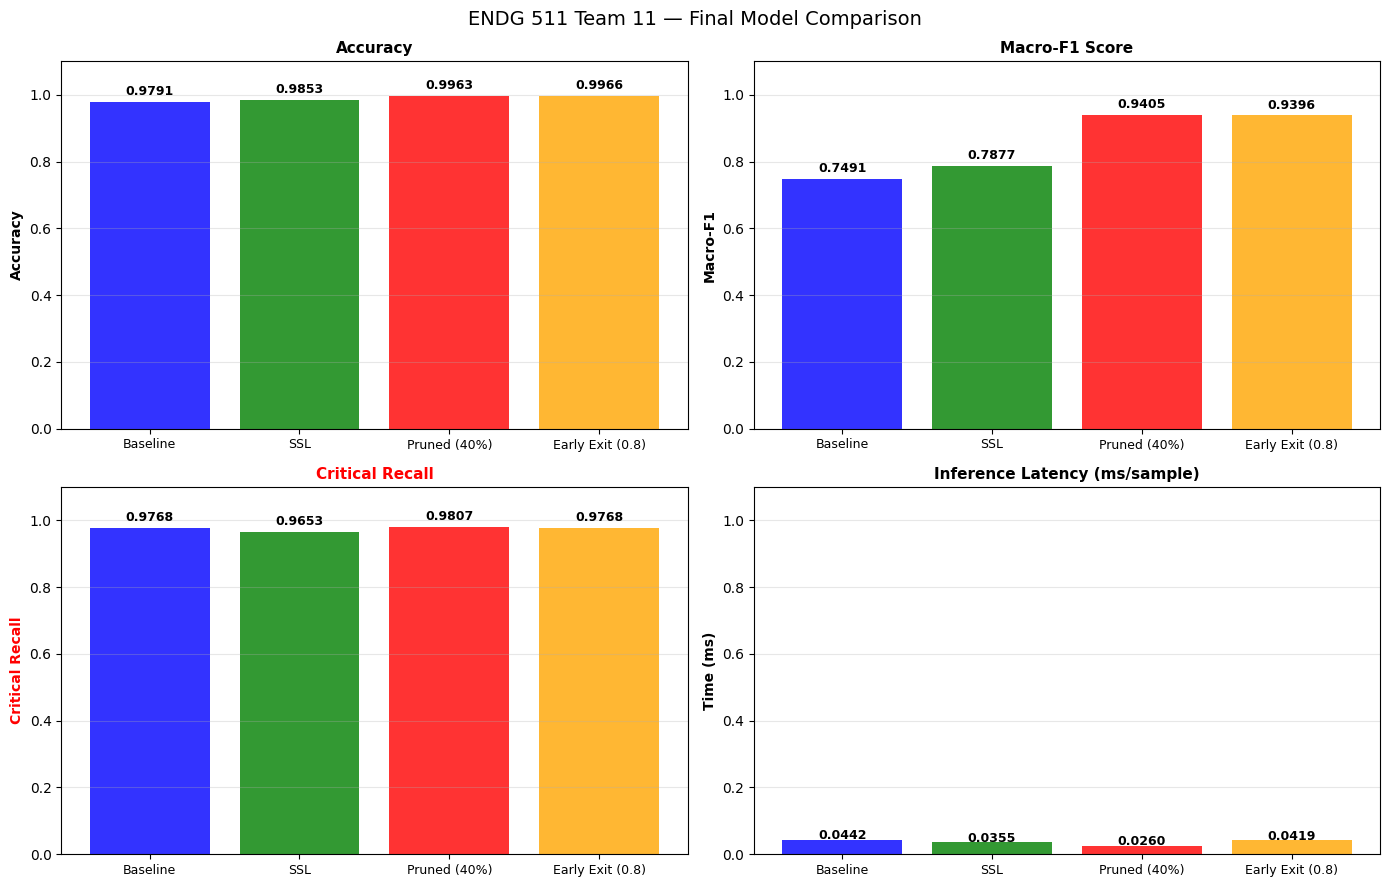

✓ Saved → final_model_comparison.png


In [43]:
# Final Model Comparison: Baseline vs SSL vs Pruning (40%) vs Early Exit (0.8)

cm_base,  acc_base,  f1_base,  cr_base = evaluate_model(baseline_model,    test_loader)
cm_ssl,   acc_ssl,   f1_ssl,   cr_ssl  = evaluate_model(ssl_finetune_model, test_loader)
cm_prune, acc_prune, f1_prune, cr_prune = evaluate_model(pruned_model,       test_loader)
cm_ee,    acc_ee,    f1_ee,    cr_ee,    ee_rate = early_exit_evaluate(early_exit_model, test_loader, threshold=0.8)

lat_base  = measure_Inference(baseline_model,    test_loader)
lat_ssl   = measure_Inference(ssl_finetune_model, test_loader)
lat_prune = measure_Inference(pruned_model,       test_loader)
lat_ee    = measure_Inference(early_exit_model,   test_loader)

n_params_prune    = sum(p.numel() for p in pruned_model.parameters())
n_params_baseline = sum(p.numel() for p in baseline_model.parameters())

#Summary Table 
comparison_df = pd.DataFrame([
    {'Model': 'Baseline',    'Accuracy': acc_base,  'Macro-F1': f1_base,  'Critical Recall': cr_base,  'Inference (ms)': lat_base,  'Notes': '-'},
    {'Model': 'SSL',         'Accuracy': acc_ssl,   'Macro-F1': f1_ssl,   'Critical Recall': cr_ssl,   'Inference (ms)': lat_ssl,   'Notes': '-'},
    {'Model': 'Pruned (40%)','Accuracy': acc_prune, 'Macro-F1': f1_prune, 'Critical Recall': cr_prune, 'Inference (ms)': lat_prune, 'Notes': f'{(1 - n_params_prune/n_params_baseline)*100:.1f}% fewer params'},
    {'Model': 'Early Exit',  'Accuracy': acc_ee,    'Macro-F1': f1_ee,    'Critical Recall': cr_ee,    'Inference (ms)': lat_ee,    'Notes': f'{ee_rate*100:.1f}% exited early'},
])
for col in ['Accuracy', 'Macro-F1', 'Critical Recall', 'Inference (ms)']:
    comparison_df[col] = comparison_df[col].round(4)

print(comparison_df.to_string(index=False))

# Plot Visuals 
models = ['Baseline', 'SSL', 'Pruned (40%)', 'Early Exit (0.8)']
colors = ['blue', 'green', 'red', 'orange']
accs  = [acc_base,  acc_ssl,  acc_prune,  acc_ee]
f1s   = [f1_base,   f1_ssl,   f1_prune,   f1_ee]
crs   = [cr_base,   cr_ssl,   cr_prune,   cr_ee]
lats  = [lat_base,  lat_ssl,  lat_prune,  lat_ee]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('ENDG 511 Team 11 — Final Model Comparison', fontsize=14)

datasets = [
    (axes[0,0], accs, 'Accuracy',            'Accuracy',          None),
    (axes[0,1], f1s,  'Macro-F1 Score',      'Macro-F1',          None),
    (axes[1,0], crs,  'Critical Recall',     'Critical Recall',   'red'),
    (axes[1,1], lats, 'Inference Latency (ms/sample)', 'Time (ms)', None),
]

for ax, vals, title, ylabel, label_color in datasets:
    bars = ax.bar(models, vals, color=colors, alpha=0.8)
    ax.set_title(title, fontweight='bold', fontsize=11,
                 color=label_color if label_color else 'black')
    ax.set_ylabel(ylabel, fontweight='bold',
                  color=label_color if label_color else 'black')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=9)
    if max(vals) <= 1:
        ax.set_ylim(0, 1.1)
    for i, v in enumerate(vals):
        fmt = f'{v:.4f}' if max(vals) <= 1 else f'{v:.4f}ms'
        ax.text(i, v + max(vals)*0.02, fmt, ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved → final_model_comparison.png')